---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/PyTorch-EE4C2C?style=for-the-badge&logo=pytorch&logoColor=white"/>
</div>

---

## Instalação das dependências

| Biblioteca | Uso |
|------------|-----|
| `numpy` | Geração e manipulação dos datasets |
| `matplotlib` | Visualizações |
| `scikit-learn` | Normalização (`StandardScaler`) e métricas |
| `torch` | Tensores, LSTM e otimizadores |

In [1]:
%pip install numpy matplotlib scikit-learn torch --quiet

Note: you may need to restart the kernel to use updated packages.


## Aula 04: Long Short-Term Memory (LSTM)

A FNN da Aula 03 trata cada exemplo de forma **independente** — não há memória entre uma entrada e a próxima. Para dados sequenciais (séries temporais, texto, sinais), a ordem importa: o que veio antes influencia o que vem depois.

As **Redes Recorrentes (RNNs)** foram criadas para isso. A LSTM é a variante mais utilizada, projetada para aprender dependências de longo prazo sem sofrer do problema do gradiente que desvanece.

### Roteiro

| Seção | Conteúdo |
|-------|----------|
| **1** | Por que RNNs? O problema das sequências |
| **2** | Arquitetura LSTM — gates e estado de célula |
| **3** | Bibliotecas e configuração |
| **4** | Caso 1: Previsão de série temporal (regressão) |
| **5** | Caso 2: Classificação de sequências |
| **6** | Comparativo e próximos passos |

---

## 1. Por que RNNs?

Uma FNN recebe um vetor fixo e produz uma saída — sem noção de tempo ou ordem. Para processar sequências, precisamos de um modelo que **mantenha estado** entre os passos:

$$h_t = f(x_t,\, h_{t-1})$$

onde $h_t$ é o **estado oculto** no passo $t$, $x_t$ é a entrada atual e $h_{t-1}$ é a memória do passo anterior.

### O problema do gradiente que desvanece

Em RNNs simples, o gradiente é multiplicado pelo mesmo peso a cada passo no tempo. Para sequências longas:

- Se o peso < 1: o gradiente **diminui exponencialmente** → a rede esquece o passado distante
- Se o peso > 1: o gradiente **explode** → treino instável

A **LSTM** resolve isso com um mecanismo de **gates** que controla seletivamente o que lembrar e o que esquecer.

---

## 2. Arquitetura LSTM

A LSTM mantém dois vetores de estado:

- $h_t$ — **estado oculto** (*hidden state*): memória de curto prazo, passada para a próxima camada
- $c_t$ — **estado de célula** (*cell state*): memória de longo prazo, protegida pelos gates

### Os três gates

| Gate | Símbolo | Função |
|------|---------|--------|
| **Forget gate** | $f_t$ | Decide o que descartar de $c_{t-1}$: $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ |
| **Input gate** | $i_t$ | Decide o que adicionar a $c_t$: $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ |
| **Output gate** | $o_t$ | Decide o que expor como $h_t$: $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ |

O estado de célula é atualizado como:

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

$$h_t = o_t \odot \tanh(c_t)$$

onde $\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$ é o candidato a nova memória e $\odot$ é a multiplicação elemento a elemento.

### FNN vs LSTM

| Aspecto | FNN (Aula 03) | LSTM (Aula 04) |
|---------|--------------|----------------|
| **Entrada** | Vetor fixo | Sequência de vetores |
| **Memória** | Nenhuma | Estado oculto $h_t$ + célula $c_t$ |
| **Uso típico** | Tabular, imagem (flat) | Séries temporais, texto, sinais |
| **PyTorch** | `nn.Linear` | `nn.LSTM` |

---

## 3. Bibliotecas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}  |  PyTorch {torch.__version__}")

Dispositivo: cpu  |  PyTorch 2.10.0


---

## 4. Caso 1: Previsão de Série Temporal (Regressão)

### 4.1 Objetivo

Dado os últimos $T$ valores de uma série temporal, prever o próximo valor — problema clássico de **previsão um passo à frente** (*one-step-ahead forecasting*).

### 4.2 Dataset

Geraremos uma série sintética composta por:

$$s(t) = \sin(2\pi f_1 t) + 0.5\,\sin(2\pi f_2 t) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,\, 0.1)$$

A soma de duas frequências cria um padrão **não-trivial** que a LSTM precisa aprender a modelar.

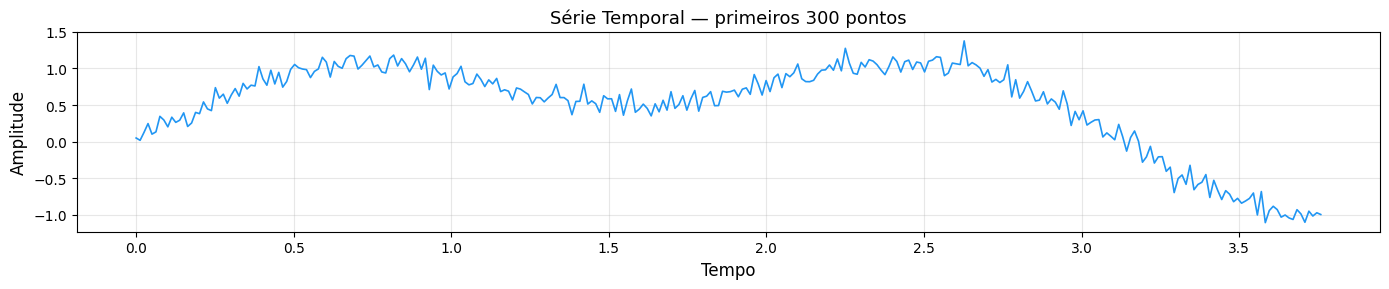

In [3]:
# Gera a série temporal
N  = 2000
t  = np.linspace(0, 8 * np.pi, N)
serie = np.sin(t) + 0.5 * np.sin(3 * t) + np.random.normal(0, 0.1, N)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t[:300], serie[:300], color="#2196F3", lw=1.2)
ax.set_xlabel("Tempo", fontsize=12)
ax.set_ylabel("Amplitude", fontsize=12)
ax.set_title("Série Temporal — primeiros 300 pontos", fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Preparação: Janela Deslizante

A LSTM recebe **sequências**. Transformamos a série em pares $(X, y)$ usando uma janela deslizante de tamanho $T$:

$$X_i = [s_{i},\, s_{i+1},\, \ldots,\, s_{i+T-1}], \quad y_i = s_{i+T}$$

Cada $X_i$ é uma sequência de $T$ passos e $y_i$ é o próximo valor a prever.

Usamos o `StandardScaler` do scikit-learn para normalizar — mais direto que funções manuais.

In [4]:
SEQ_LEN = 30   # tamanho da janela de entrada

# Normalização com StandardScaler
scaler = StandardScaler()
serie_norm = scaler.fit_transform(serie.reshape(-1, 1)).flatten()

# Janela deslizante
X = np.array([serie_norm[i : i + SEQ_LEN] for i in range(len(serie_norm) - SEQ_LEN)])
y = serie_norm[SEQ_LEN:]

# Divisão treino/teste 80/20 (sem embaralhar — preserva ordem temporal)
n_treino = int(0.8 * len(X))
X_tr, X_te = X[:n_treino], X[n_treino:]
y_tr, y_te = y[:n_treino], y[n_treino:]

# Tensores — LSTM espera (batch, seq_len, features)
X_tr_t = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(-1).to(device)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(-1).to(device)
X_te_t = torch.tensor(X_te, dtype=torch.float32).unsqueeze(-1).to(device)
y_te_t = torch.tensor(y_te, dtype=torch.float32).unsqueeze(-1).to(device)

loader_tr = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

print(f"Shape X_tr_t: {X_tr_t.shape}  →  (amostras, seq_len, features)")
print(f"Shape y_tr_t: {y_tr_t.shape}")
print(f"Treino: {len(X_tr)} | Teste: {len(X_te)}")

Shape X_tr_t: torch.Size([1576, 30, 1])  →  (amostras, seq_len, features)
Shape y_tr_t: torch.Size([1576, 1])
Treino: 1576 | Teste: 394


### 4.4 Modelo LSTM

O `nn.LSTM` do PyTorch processa a sequência inteira e retorna:
- `output`: saída $h_t$ em **cada** passo de tempo — shape `(batch, seq_len, hidden_size)`
- `(h_n, c_n)`: estado oculto e de célula do **último** passo

Para previsão, usamos apenas a saída do **último passo** (`output[:, -1, :]`), que carrega toda a informação acumulada da sequência.

In [5]:
class PrevisaoLSTM(nn.Module):
    """LSTM para previsão de série temporal (many-to-one)."""

    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,      # entrada: (batch, seq, features)
            dropout=dropout,
        )
        self.fc = nn.Linear(hidden_size, 1)   # saída linear — regressão

    def forward(self, x):
        output, _ = self.lstm(x)       # (batch, seq_len, hidden_size)
        return self.fc(output[:, -1])  # usa apenas o último passo


modelo_reg = PrevisaoLSTM().to(device)
print(modelo_reg)
n_params = sum(p.numel() for p in modelo_reg.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {n_params:,}")

PrevisaoLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parâmetros treináveis: 50,497


### 4.5 Treinamento

In [6]:
criterio   = nn.MSELoss()
otimizador = optim.Adam(modelo_reg.parameters(), lr=0.001)
epocas     = 50

hist_tr, hist_te = [], []

for epoca in range(1, epocas + 1):

    modelo_reg.train()
    loss_tr = 0.0
    for xb, yb in loader_tr:
        otimizador.zero_grad()
        loss = criterio(modelo_reg(xb), yb)
        loss.backward()
        otimizador.step()
        loss_tr += loss.item()
    loss_tr /= len(loader_tr)

    modelo_reg.eval()
    with torch.no_grad():
        loss_te = criterio(modelo_reg(X_te_t), y_te_t).item()

    hist_tr.append(loss_tr)
    hist_te.append(loss_te)

    if epoca % 10 == 0 or epoca == 1:
        print(f"Época {epoca:>3} | Loss Treino: {loss_tr:.5f} | Loss Teste: {loss_te:.5f}")

print("\nTreinamento concluído!")


Época   1 | Loss Treino: 0.53118 | Loss Teste: 0.12378
Época  10 | Loss Treino: 0.02318 | Loss Teste: 0.02117
Época  20 | Loss Treino: 0.02099 | Loss Teste: 0.01942
Época  30 | Loss Treino: 0.02277 | Loss Teste: 0.01955
Época  40 | Loss Treino: 0.02137 | Loss Teste: 0.02105
Época  50 | Loss Treino: 0.02198 | Loss Teste: 0.01983

Treinamento concluído!


### 4.6 Resultados

RMSE (escala original): 0.1119


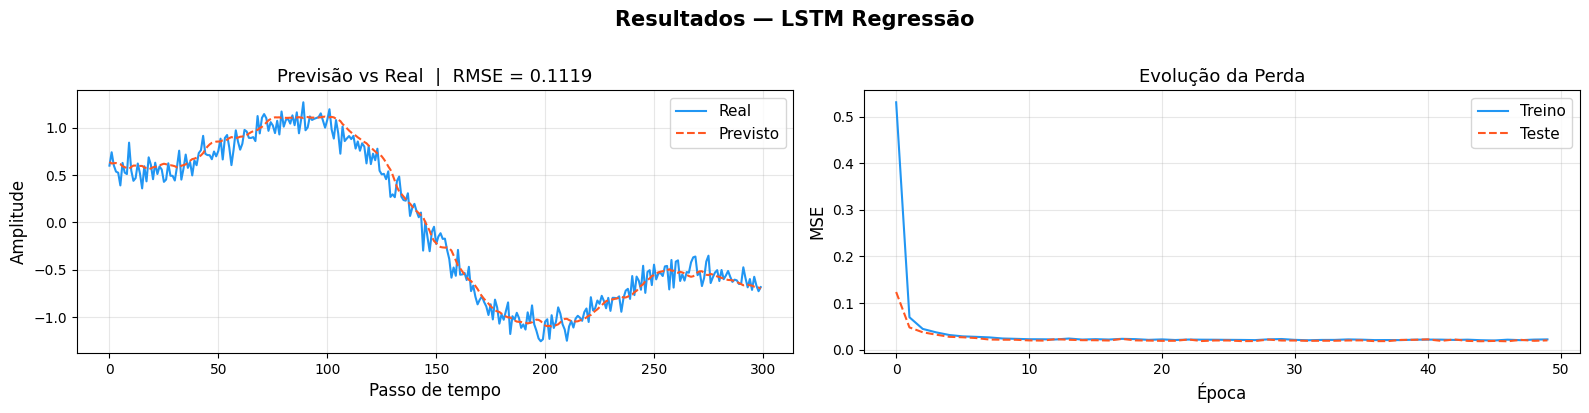

In [7]:
modelo_reg.eval()
with torch.no_grad():
    pred_norm = modelo_reg(X_te_t).cpu().numpy().flatten()

# Reverte normalização
pred_orig = scaler.inverse_transform(pred_norm.reshape(-1, 1)).flatten()
real_orig = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

rmse = np.sqrt(np.mean((real_orig - pred_orig)**2))
print(f"RMSE (escala original): {rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Painel 1 — Série prevista vs real
ax = axes[0]
n_plot = 300
ax.plot(real_orig[:n_plot], label="Real",   color="#2196F3", lw=1.5)
ax.plot(pred_orig[:n_plot], label="Previsto", color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Passo de tempo", fontsize=12)
ax.set_ylabel("Amplitude", fontsize=12)
ax.set_title(f"Previsão vs Real  |  RMSE = {rmse:.4f}", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Painel 2 — Curva de perda
ax = axes[1]
ax.plot(hist_tr, label="Treino", color="#2196F3", lw=1.5)
ax.plot(hist_te, label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("MSE", fontsize=12)
ax.set_title("Evolução da Perda", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.suptitle("Resultados — LSTM Regressão", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

## 5. Caso 2: Classificação de Sequências

### 5.1 Objetivo

Classificar sequências de comprimento fixo em 3 tipos com base no seu padrão temporal — o modelo precisa entender o **comportamento ao longo do tempo**, não apenas valores pontuais.

### 5.2 Dataset

Geraremos 3 classes de sequências:

| Classe | Padrão | Descrição |
|--------|--------|----------|
| **0** | Senoidal | $\sin(\omega t + \phi)$ com frequência e fase aleatórias |
| **1** | Tendência linear | Sequência crescente ou decrescente com ruído |
| **2** | Ruído aleatório | Processo estocástico sem estrutura |

In [8]:
def criar_dataset_sequencias(n_por_classe=500, seq_len=50, seed=42):
    """Gera 3 tipos de sequências: senoidal, tendência linear e ruído."""
    rng = np.random.default_rng(seed)
    X, y = [], []

    for _ in range(n_por_classe):
        t = np.linspace(0, 2 * np.pi, seq_len)

        # Classe 0 — senoidal (frequência e fase aleatórias)
        freq  = rng.uniform(1, 4)
        fase  = rng.uniform(0, np.pi)
        X.append(np.sin(freq * t + fase) + rng.normal(0, 0.1, seq_len))
        y.append(0)

        # Classe 1 — tendência linear
        slope = rng.choice([-1, 1]) * rng.uniform(0.5, 2)
        X.append(slope * np.linspace(0, 1, seq_len) + rng.normal(0, 0.1, seq_len))
        y.append(1)

        # Classe 2 — ruído aleatório
        X.append(rng.normal(0, 1, seq_len))
        y.append(2)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    idx = rng.permutation(len(y))
    return X[idx], y[idx]


SEQ_LEN_CLF = 50
X_clf, y_clf = criar_dataset_sequencias(n_por_classe=500, seq_len=SEQ_LEN_CLF)
print(f"Shape X: {X_clf.shape}  |  Shape y: {y_clf.shape}")
print(f"Classes: { {k: int((y_clf == k).sum()) for k in range(3)} }")

Shape X: (1500, 50)  |  Shape y: (1500,)
Classes: {0: 500, 1: 500, 2: 500}


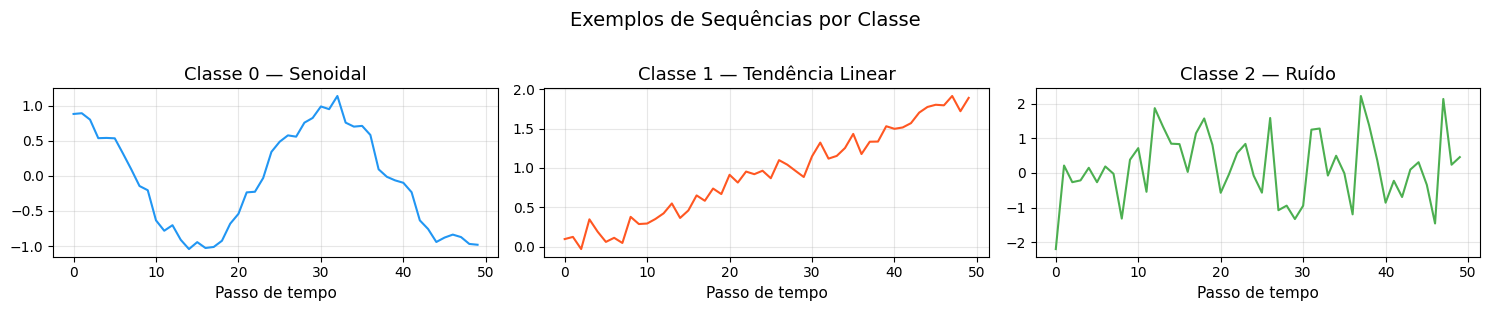

In [9]:
# Visualiza um exemplo de cada classe
nomes_clf = ["Classe 0 — Senoidal", "Classe 1 — Tendência Linear", "Classe 2 — Ruído"]
cores_clf = ["#2196F3", "#FF5722", "#4CAF50"]

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for k, (ax, nome, cor) in enumerate(zip(axes, nomes_clf, cores_clf)):
    exemplo = X_clf[y_clf == k][0]
    ax.plot(exemplo, color=cor, lw=1.5)
    ax.set_title(nome, fontsize=13)
    ax.set_xlabel("Passo de tempo", fontsize=11)
    ax.grid(alpha=0.3)

plt.suptitle("Exemplos de Sequências por Classe", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Preparação dos Dados

In [10]:
# Normalização por sequência (cada amostra individualmente)
scaler_clf = StandardScaler()
X_clf_norm = scaler_clf.fit_transform(X_clf)

# Divisão treino/teste 80/20
n_tr = int(0.8 * len(X_clf_norm))
X_tr_c, X_te_c = X_clf_norm[:n_tr], X_clf_norm[n_tr:]
y_tr_c, y_te_c = y_clf[:n_tr],      y_clf[n_tr:]

# Tensores — LSTM espera (batch, seq_len, features)
X_tr_ct = torch.tensor(X_tr_c, dtype=torch.float32).unsqueeze(-1).to(device)
y_tr_ct = torch.tensor(y_tr_c, dtype=torch.long).to(device)
X_te_ct = torch.tensor(X_te_c, dtype=torch.float32).unsqueeze(-1).to(device)
y_te_ct = torch.tensor(y_te_c, dtype=torch.long).to(device)

loader_tr_c = DataLoader(TensorDataset(X_tr_ct, y_tr_ct), batch_size=64, shuffle=True)

print(f"Shape X_tr_ct: {X_tr_ct.shape}  →  (amostras, seq_len, features)")
print(f"Treino: {len(X_tr_c)} | Teste: {len(X_te_c)}")

Shape X_tr_ct: torch.Size([1200, 50, 1])  →  (amostras, seq_len, features)
Treino: 1200 | Teste: 300


### 5.4 Modelo LSTM para Classificação

A estrutura é idêntica à de regressão, exceto pela camada de saída:
- **Regressão**: `nn.Linear(hidden, 1)` — valor contínuo
- **Classificação**: `nn.Linear(hidden, n_classes)` — logits por classe

Assim como na Aula 03, usamos `CrossEntropyLoss` (softmax embutido) e a saída é linear.

In [11]:
class ClassificacaoLSTM(nn.Module):
    """LSTM para classificação de sequências (many-to-one)."""

    def __init__(self, input_size=1, hidden_size=64, num_layers=2,
                 n_classes=3, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.fc = nn.Linear(hidden_size, n_classes)   # logits — sem softmax

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.fc(output[:, -1])   # último passo de tempo


modelo_clf = ClassificacaoLSTM().to(device)
print(modelo_clf)
n_params_c = sum(p.numel() for p in modelo_clf.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {n_params_c:,}")

ClassificacaoLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

Parâmetros treináveis: 50,627


### 5.5 Treinamento

In [12]:
criterio_clf   = nn.CrossEntropyLoss()
otimizador_clf = optim.Adam(modelo_clf.parameters(), lr=0.001)
epocas_clf     = 50

hist_loss_tr_c, hist_loss_te_c = [], []
hist_acc_tr_c,  hist_acc_te_c  = [], []

for epoca in range(1, epocas_clf + 1):

    modelo_clf.train()
    loss_tr, acc_tr, n_batches = 0.0, 0.0, 0
    for xb, yb in loader_tr_c:
        otimizador_clf.zero_grad()
        logits = modelo_clf(xb)
        loss   = criterio_clf(logits, yb)
        loss.backward()
        otimizador_clf.step()
        loss_tr += loss.item()
        acc_tr  += (logits.argmax(1) == yb).float().mean().item()
        n_batches += 1
    loss_tr /= n_batches
    acc_tr  /= n_batches

    modelo_clf.eval()
    with torch.no_grad():
        logits_te = modelo_clf(X_te_ct)
        loss_te   = criterio_clf(logits_te, y_te_ct).item()
        acc_te    = (logits_te.argmax(1) == y_te_ct).float().mean().item()

    hist_loss_tr_c.append(loss_tr);  hist_loss_te_c.append(loss_te)
    hist_acc_tr_c.append(acc_tr);    hist_acc_te_c.append(acc_te)

    if epoca % 10 == 0 or epoca == 1:
        print(f"Época {epoca:>3} | Loss: {loss_tr:.4f} "
              f"| Acc Treino: {acc_tr:.3f} | Acc Teste: {acc_te:.3f}")

print(f"\nAcurácia final no teste: {hist_acc_te_c[-1]*100:.2f}%")

Época   1 | Loss: 1.0986 | Acc Treino: 0.349 | Acc Teste: 0.393
Época  10 | Loss: 0.4628 | Acc Treino: 0.762 | Acc Teste: 0.777
Época  20 | Loss: 0.1691 | Acc Treino: 0.938 | Acc Teste: 0.930
Época  30 | Loss: 0.0078 | Acc Treino: 0.998 | Acc Teste: 0.990
Época  40 | Loss: 0.0175 | Acc Treino: 0.993 | Acc Teste: 0.987
Época  50 | Loss: 0.0019 | Acc Treino: 1.000 | Acc Teste: 0.997

Acurácia final no teste: 99.67%


### 5.6 Resultados

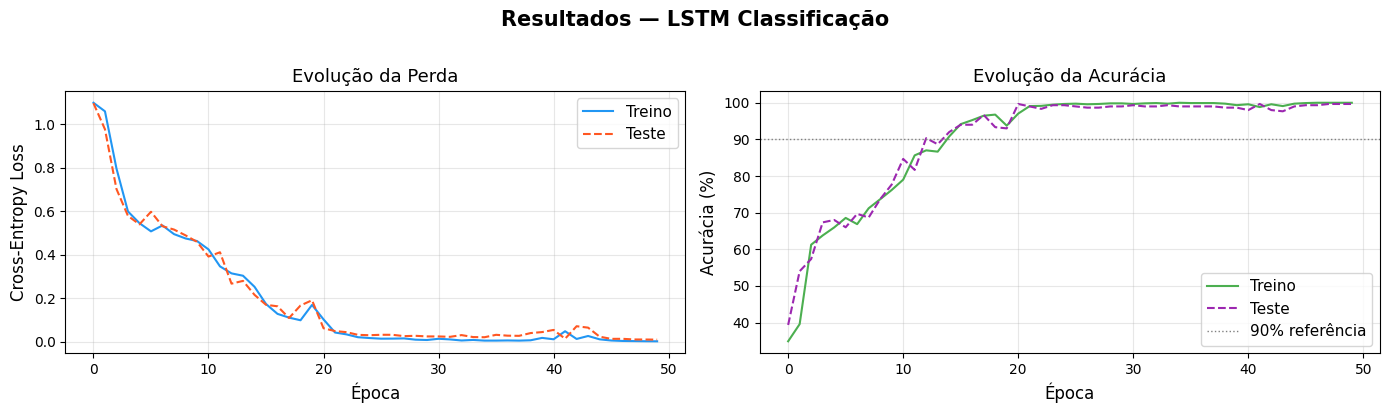

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(hist_loss_tr_c, label="Treino", color="#2196F3", lw=1.5)
ax.plot(hist_loss_te_c, label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Evolução da Perda", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot([a * 100 for a in hist_acc_tr_c], label="Treino", color="#4CAF50", lw=1.5)
ax.plot([a * 100 for a in hist_acc_te_c], label="Teste",  color="#9C27B0", lw=1.5, linestyle="--")
ax.axhline(90, color="gray", lw=1, linestyle=":", label="90% referência")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Acurácia (%)", fontsize=12)
ax.set_title("Evolução da Acurácia", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.suptitle("Resultados — LSTM Classificação", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

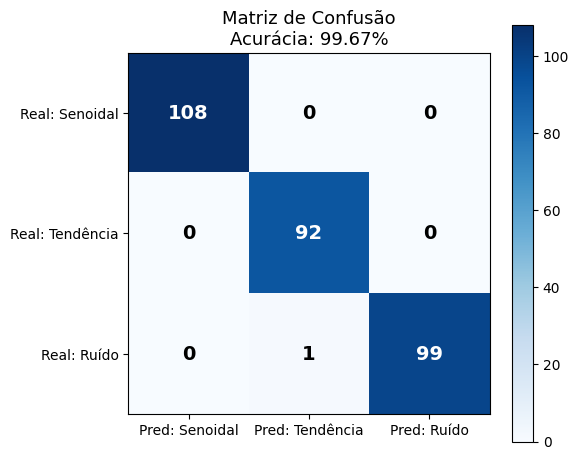

In [14]:
# Matriz de confusão
modelo_clf.eval()
with torch.no_grad():
    pred_te = modelo_clf(X_te_ct).argmax(1).cpu().numpy()

matriz = np.zeros((3, 3), dtype=int)
np.add.at(matriz, (y_te_c, pred_te), 1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz, cmap="Blues")
plt.colorbar(im, ax=ax)
for i in range(3):
    for j in range(3):
        cor = "white" if matriz[i, j] > matriz.max() * 0.6 else "black"
        ax.text(j, i, str(matriz[i, j]), ha="center", va="center",
                fontsize=14, color=cor, fontweight="bold")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
rotulos = ["Senoidal", "Tendência", "Ruído"]
ax.set_xticklabels([f"Pred: {r}" for r in rotulos], fontsize=10)
ax.set_yticklabels([f"Real: {r}" for r in rotulos], fontsize=10)
ax.set_title(f"Matriz de Confusão\nAcurácia: {hist_acc_te_c[-1]*100:.2f}%", fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. Comparativo e Próximos Passos

### 6.1 FNN vs LSTM

| Aspecto | FNN (Aula 03) | LSTM (Aula 04) |
|---------|--------------|----------------|
| **Entrada** | Vetor fixo $(batch, features)$ | Sequência $(batch, seq\_len, features)$ |
| **Memória** | Nenhuma | $h_t$ e $c_t$ persistem entre passos |
| **Parâmetros** | Crescem com features | Crescem com `hidden_size` |
| **Dados temporais** | Trata passos como independentes | Captura dependências temporais |
| **Saída** | Vetor único | Vetor por passo ou apenas o último |

### 6.2 Many-to-One vs Many-to-Many

Nesta aula usamos a arquitetura **many-to-one**: a LSTM processa toda a sequência e gera uma única saída no último passo. Existem outras configurações:

| Configuração | Uso | Como implementar |
|-------------|-----|------------------|
| **Many-to-one** | Classificação, previsão de um passo | `output[:, -1, :]` |
| **Many-to-many** | Tradução, geração de sequências | `output` completo |
| **One-to-many** | Legenda de imagem, síntese | Entrada repetida a cada passo |

### 6.3 Próximos Passos

| Tópico | O que resolve |
|--------|---------------|
| **GRU** | Variante mais simples da LSTM — menos parâmetros, desempenho similar |
| **LSTM bidirecional** | Lê a sequência nos dois sentidos — captura contexto futuro |
| **Attention** | Pondera a importância de cada passo — base dos Transformers |
| **Transformer** | Substitui recorrência por atenção global — estado da arte em sequências |

In [15]:
print("=" * 58)
print(" RESUMO — Aula 04: LSTM com PyTorch")
print("=" * 58)
print()
print(" CASO 1 — REGRESSÃO (previsão de série temporal)")
print(f"   Arquitetura : LSTM(hidden=64, layers=2) -> Linear(1)")
print(f"   Seq. length : {SEQ_LEN} passos")
print(f"   RMSE final  : {rmse:.4f} (escala original)")
print()
print(" CASO 2 — CLASSIFICAÇÃO (tipo de sequência)")
print(f"   Arquitetura : LSTM(hidden=64, layers=2) -> Linear(3)")
print(f"   Seq. length : {SEQ_LEN_CLF} passos")
print(f"   Acurácia    : {hist_acc_te_c[-1]*100:.2f}%")
print()
print("=" * 58)

 RESUMO — Aula 04: LSTM com PyTorch

 CASO 1 — REGRESSÃO (previsão de série temporal)
   Arquitetura : LSTM(hidden=64, layers=2) -> Linear(1)
   Seq. length : 30 passos
   RMSE final  : 0.1119 (escala original)

 CASO 2 — CLASSIFICAÇÃO (tipo de sequência)
   Arquitetura : LSTM(hidden=64, layers=2) -> Linear(3)
   Seq. length : 50 passos
   Acurácia    : 99.67%

